In [1]:
import numpy as np
import libpysal as ps
import missingno as msno
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
import geopandas as gdp
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.font_manager as fm
from matplotlib import font_manager, rc
import seaborn as sns
import warnings
from mgwr.utils import shift_colormap, truncate_colormap

In [2]:
mpl.rcParams['axes.unicode_minus'] = False
warnings.simplefilter('ignore')

In [3]:
from tqdm import tqdm_notebook
from sklearn.model_selection import KFold, StratifiedKFold
warnings.simplefilter('ignore')


In [4]:
ped_data = pd.read_csv('D:/Analysis/BigData-PythonAnalysis-main/서울시_집계구_보행.csv',encoding="EUC-KR")
seoul_shp = gdp.read_file('D:/Analysis/BigData-PythonAnalysis-main/서울/서울시_집계구_4326.shp',encoding="EUC-KR")


In [5]:
ped_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19153 entries, 0 to 19152
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TOT_REG_CD  19153 non-null  int64  
 1   공공기관        19153 non-null  int64  
 2   보육시설        19153 non-null  int64  
 3   사회복지시       19153 non-null  int64  
 4   버스정류장수      19153 non-null  int64  
 5   버스승하차       19153 non-null  float64
 6   지하철(1km이내)  19153 non-null  int64  
 7   지하철거리점수     19143 non-null  float64
 8   지하철승하차      19153 non-null  int64  
 9   구별총생활       19153 non-null  int64  
 10  구별총생활인구     19153 non-null  float64
 11  상가수         19143 non-null  float64
 12  어린이집개수      18738 non-null  float64
 13  면적          19153 non-null  int64  
 14  병원수         19153 non-null  int64  
dtypes: float64(5), int64(10)
memory usage: 2.2 MB


In [5]:

seoul_shp.to_crs(epsg=4326)
seoul_shp.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
ped_data.rename(columns={'사회복지시':'SOC_NUM','지하철(1km이내)':'SUB_NUM','지하철거리점수':'SUB_DIS_POINT'
 ,'버스정류장수':'BUS_NUM','버스승하차':'BUS_AVG','지하철승하차':'SUB_AVG'
 ,'구별총생활':'TOT_POP_GU','구별총생활인구':'TOT_POP_GU_AVG','상가수':'SHOP_NUM'
 , '어린이집개수':'CHILD_NUM','면적':'AREA','병원수':'HOSP_NUM'}
 ,inplace=True)

In [8]:
display(ped_data.columns)

Index(['TOT_REG_CD', '공공기관', '보육시설', 'SOC_NUM', 'BUS_NUM', 'BUS_AVG',
       'SUB_NUM', 'SUB_DIS_POINT', 'SUB_AVG', 'TOT_POP_GU', 'TOT_POP_GU_AVG',
       'SHOP_NUM', 'CHILD_NUM', 'AREA', 'HOSP_NUM'],
      dtype='object')

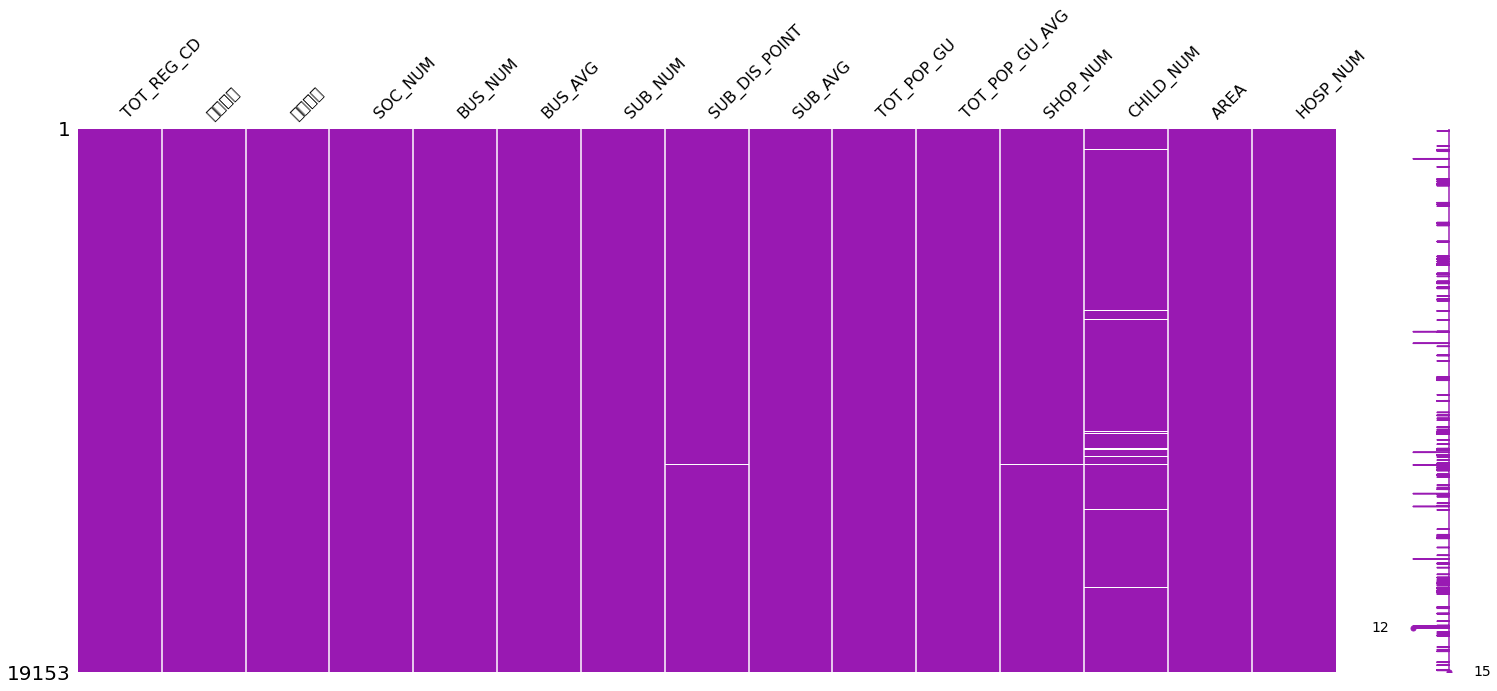

In [9]:
msno.matrix(df=ped_data,color=(0.6,0.1,0.7))
plt.show()

In [108]:
ped_data.isnull().sum()

TOT_REG_CD          0
공공기관                0
보육시설                0
SOC_NUM             0
BUS_NUM             0
BUS_AVG             0
SUB_NUM             0
SUB_DIS_POINT      10
SUB_AVG             0
TOT_POP_GU          0
TOT_POP_GU_AVG      0
SHOP_NUM           10
CHILD_NUM         415
AREA                0
HOSP_NUM            0
dtype: int64

In [7]:
ped_data['SUB_DIS_POINT'].fillna(0,inplace=True)
ped_data['SUB_DIS_POINT'].isnull().sum()

0

In [8]:
ped_data['SHOP_NUM'].fillna(0,inplace=True)
ped_data['SHOP_NUM'].isnull().sum()

0

In [9]:
ped_data['CHILD_NUM'].fillna(0,inplace=True)
ped_data['SHOP_NUM'].isnull().sum()

0

In [13]:
ped_data.isnull().sum()

TOT_REG_CD        0
공공기관              0
보육시설              0
SOC_NUM           0
BUS_NUM           0
BUS_AVG           0
SUB_NUM           0
SUB_DIS_POINT     0
SUB_AVG           0
TOT_POP_GU        0
TOT_POP_GU_AVG    0
SHOP_NUM          0
CHILD_NUM         0
AREA              0
HOSP_NUM          0
dtype: int64

In [113]:
#ped_data.to_csv('D:/Analysis/BigData-PythonAnalysis-main/서울시_집계구_보행_결측처리.csv',encoding = 'utf8')

In [10]:
ped_data['FACILITY_NUM'] = (ped_data['공공기관']+ped_data['보육시설']+ped_data['CHILD_NUM']+ped_data['SOC_NUM'])

In [11]:
ped_data = ped_data.drop(['공공기관','보육시설','CHILD_NUM','SOC_NUM'],axis = 1)

In [12]:
ped_data['TOT_REG_CD']=ped_data['TOT_REG_CD'].astype(str)

In [13]:
data = ped_data.merge(seoul_shp,left_on='TOT_REG_CD',right_on='TOT_REG_CD')
data.head()

,TOT_REG_CD,BUS_NUM,BUS_AVG,SUB_NUM,SUB_DIS_POINT,SUB_AVG,TOT_POP_GU,TOT_POP_GU_AVG,SHOP_NUM,AREA,HOSP_NUM,FACILITY_NUM,ADM_NM,ADM_CD,geometry
0,1101053010001,3,196.559140,4,24.0,0,277143,8940.096774,7.0,18821,0,16.0,사직동,1101053,"POLYGON ((126.96613 37.57496, 126.96632 37.574..."
1,1101053010002,2,428.177419,3,27.0,52315,1373417,44303.774190,74.0,37082,0,16.0,사직동,1101053,"POLYGON ((126.96877 37.57823, 126.96878 37.578..."
2,1101053010003,12,497.196237,4,26.0,34690,1245899,40190.290320,37.0,218981,0,26.0,사직동,1101053,"POLYGON ((126.96645 37.57883, 126.96647 37.578..."
3,1101053010004,5,3152.083871,4,29.0,52315,1515584,48889.806450,113.0,44920,0,22.0,사직동,1101053,"POLYGON ((126.97145 37.57734, 126.97147 37.577..."
4,1101053010005,6,2136.021505,3,29.0,52315,1038484,33499.483870,122.0,70996,0,24.0,사직동,1101053,"POLYGON ((126.97399 37.57823, 126.97400 37.578..."


In [78]:
'''
#지하철 거리 제외
essential_col=['TOT_REG_CD','BUS_NUM','SUB_NUM','SHOP_NUM','FACILITY_NUM','HOSP_NUM','geometry','TOT_POP_GU_AVG']
required_data = data.loc[:,essential_col]
required_data.head()
'''

,TOT_REG_CD,BUS_NUM,SUB_NUM,SHOP_NUM,FACILITY_NUM,HOSP_NUM,geometry,TOT_POP_GU_AVG
0,1101053010001,3,4,7.0,16.0,0,"POLYGON ((126.96613 37.57496, 126.96632 37.574...",8940.096774
1,1101053010002,2,3,74.0,16.0,0,"POLYGON ((126.96877 37.57823, 126.96878 37.578...",44303.774190
2,1101053010003,12,4,37.0,26.0,0,"POLYGON ((126.96645 37.57883, 126.96647 37.578...",40190.290320
3,1101053010004,5,4,113.0,22.0,0,"POLYGON ((126.97145 37.57734, 126.97147 37.577...",48889.806450
4,1101053010005,6,3,122.0,24.0,0,"POLYGON ((126.97399 37.57823, 126.97400 37.578...",33499.483870


In [14]:
#기본

essential_col=['TOT_REG_CD','BUS_NUM','SUB_NUM','SUB_DIS_POINT','SHOP_NUM','FACILITY_NUM','HOSP_NUM','geometry','TOT_POP_GU_AVG']
required_data = data.loc[:,essential_col]
required_data.head()


,TOT_REG_CD,BUS_NUM,SUB_NUM,SUB_DIS_POINT,SHOP_NUM,FACILITY_NUM,HOSP_NUM,geometry,TOT_POP_GU_AVG
0,1101053010001,3,4,24.0,7.0,16.0,0,"POLYGON ((126.96613 37.57496, 126.96632 37.574...",8940.096774
1,1101053010002,2,3,27.0,74.0,16.0,0,"POLYGON ((126.96877 37.57823, 126.96878 37.578...",44303.774190
2,1101053010003,12,4,26.0,37.0,26.0,0,"POLYGON ((126.96645 37.57883, 126.96647 37.578...",40190.290320
3,1101053010004,5,4,29.0,113.0,22.0,0,"POLYGON ((126.97145 37.57734, 126.97147 37.577...",48889.806450
4,1101053010005,6,3,29.0,122.0,24.0,0,"POLYGON ((126.97399 37.57823, 126.97400 37.578...",33499.483870


In [38]:
#병원제외
'''
essential_col=['TOT_REG_CD','BUS_NUM','SUB_NUM','SUB_DIS_POINT','SHOP_NUM','FACILITY_NUM','geometry','TOT_POP_GU_AVG']
required_data = data.loc[:,essential_col]
required_data.head()
'''

,TOT_REG_CD,BUS_NUM,SUB_NUM,SUB_DIS_POINT,SHOP_NUM,FACILITY_NUM,geometry,TOT_POP_GU_AVG
0,1101053010001,3,4,24.0,7.0,16.0,"POLYGON ((126.96613 37.57496, 126.96632 37.574...",8940.096774
1,1101053010002,2,3,27.0,74.0,16.0,"POLYGON ((126.96877 37.57823, 126.96878 37.578...",44303.774190
2,1101053010003,12,4,26.0,37.0,26.0,"POLYGON ((126.96645 37.57883, 126.96647 37.578...",40190.290320
3,1101053010004,5,4,29.0,113.0,22.0,"POLYGON ((126.97145 37.57734, 126.97147 37.577...",48889.806450
4,1101053010005,6,3,29.0,122.0,24.0,"POLYGON ((126.97399 37.57823, 126.97400 37.578...",33499.483870


In [15]:
center = seoul_shp.centroid
X = pd.Series(center.x)
Y = pd.Series(center.y)
required_data.loc[:,'lon'] = X
required_data.loc[:,'lat'] = Y
required_data.head()

,TOT_REG_CD,BUS_NUM,SUB_NUM,SUB_DIS_POINT,SHOP_NUM,FACILITY_NUM,HOSP_NUM,geometry,TOT_POP_GU_AVG,lon,lat
0,1101053010001,3,4,24.0,7.0,16.0,0,"POLYGON ((126.96613 37.57496, 126.96632 37.574...",8940.096774,126.970311,37.578304
1,1101053010002,2,3,27.0,74.0,16.0,0,"POLYGON ((126.96877 37.57823, 126.96878 37.578...",44303.774190,126.965178,37.574151
2,1101053010003,12,4,26.0,37.0,26.0,0,"POLYGON ((126.96645 37.57883, 126.96647 37.578...",40190.290320,126.965513,37.576513
3,1101053010004,5,4,29.0,113.0,22.0,0,"POLYGON ((126.97145 37.57734, 126.97147 37.577...",48889.806450,126.969002,37.577092
4,1101053010005,6,3,29.0,122.0,24.0,0,"POLYGON ((126.97399 37.57823, 126.97400 37.578...",33499.483870,126.972772,37.578025


In [16]:
essential_col[1:-2]

['BUS_NUM', 'SUB_NUM', 'SUB_DIS_POINT', 'SHOP_NUM', 'FACILITY_NUM', 'HOSP_NUM']

In [17]:
s_y = required_data['TOT_POP_GU_AVG'].values.reshape((-1,1))
s_X = required_data[essential_col[1:-2]].values
u = required_data['lon']
v = required_data['lat']
s_coords = list(zip(u,v))

In [22]:
gwr_selector = Sel_BW(s_coords, s_y, s_X,kernel='gaussian')
gwr_bw = gwr_selector.search(bw_min=2)
print(gwr_bw)
gwr_model = GWR(s_coords, s_y, s_X, gwr_bw,kernel='gaussian')
gwr_results = gwr_model.fit()

13.0


In [29]:
print('Bandwidth :',gwr_bw )

Bandwidth : 13.0


In [23]:
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                               19153
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       4057505279198.900
Log-likelihood:                                                 -210771.600
AIC:                                                             421557.201
AICc:                                                            421559.208
BIC:                                                           4057505090415.230
R2:                                                                   0.571
Adj. R2:                                                              0.571

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- -------

In [24]:
scale = gwr_results.scale
residuals = gwr_results.resid_response

In [25]:
pred_u = required_data['lon'].values
pred_v = required_data['lat'].values
pred_coords = list(zip(pred_u,pred_v))

In [26]:
pred_results = gwr_model.predict(np.array(pred_coords), s_X, scale, residuals)


In [27]:
import math

In [28]:
MAE = abs(s_y.flatten() - pred_results.predictions.flatten()).mean()
MSE = math.sqrt(((s_y.flatten() - pred_results.predictions.flatten())**2).mean())
MAPE = (abs(s_y.flatten() - pred_results.predictions.flatten())/s_y.flatten()*100).mean()
pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T

,MAE,MSE,MAPE
Score,4679.293831,7834.389169,73.231844


In [160]:
required_data.to_csv('D:/Analysis/BigData-PythonAnalysis-main/사용DF.csv',encoding = 'utf8')

In [161]:
df1.to_csv('D:/Analysis/BigData-PythonAnalysis-main/prediction.csv',encoding = 'utf8')

In [51]:
visualization_data = required_data.copy()
visualization_data.head()

,TOT_REG_CD,BUS_NUM,SUB_NUM,SUB_DIS_POINT,SHOP_NUM,FACILITY_NUM,geometry,TOT_POP_GU_AVG,lon,lat
0,1101053010001,3,4,24.0,7.0,16.0,"POLYGON ((126.96613 37.57496, 126.96632 37.574...",8940.096774,126.970311,37.578304
1,1101053010002,2,3,27.0,74.0,16.0,"POLYGON ((126.96877 37.57823, 126.96878 37.578...",44303.774190,126.965178,37.574151
2,1101053010003,12,4,26.0,37.0,26.0,"POLYGON ((126.96645 37.57883, 126.96647 37.578...",40190.290320,126.965513,37.576513
3,1101053010004,5,4,29.0,113.0,22.0,"POLYGON ((126.97145 37.57734, 126.97147 37.577...",48889.806450,126.969002,37.577092
4,1101053010005,6,3,29.0,122.0,24.0,"POLYGON ((126.97399 37.57823, 126.97400 37.578...",33499.483870,126.972772,37.578025


In [53]:
visualization_data['gwr_intercept'] = gwr_results.params[:,0]
visualization_data['gwr_bus_num'] = gwr_results.params[:,1]
visualization_data['gwr_sub_num'] = gwr_results.params[:,2]
visualization_data['gwr_sub_dis_point'] = gwr_results.params[:,3]
visualization_data['gwr_shop_num'] = gwr_results.params[:,4]
visualization_data['gwr_facility_num'] = gwr_results.params[:,5]

In [54]:
columns = ['geometry','gwr_intercept','gwr_bus_num','gwr_sub_num','gwr_sub_dis_point','gwr_shop_num','gwr_facility_num']


In [55]:
s_geo_data = visualization_data.loc[:,columns]
s_geo_data = gdp.GeoDataFrame(s_geo_data,geometry='geometry')


In [56]:
s_geo_data.to_file('D:/Analysis/BigData-PythonAnalysis-main/서울/GWRparams_nothosp.shp', driver='ESRI Shapefile')

# 검증용 예측모델

In [18]:
col = essential_col[1:-2]
col.append('lon')
col.append('lat')
display(col)
s_y = required_data['TOT_POP_GU_AVG']
s_X = required_data[col]
# test set은 20%, 
x_train, x_valid, y_train, y_valid = train_test_split(s_X, s_y, test_size=0.2, shuffle=True,random_state=34)
cal_u = x_train['lon'].values
cal_v = x_train['lat'].values
cal_coords = list(zip(cal_u,cal_v))
pred_u = x_valid['lon'].values
pred_v = x_valid['lat'].values
pred_coords = list(zip(pred_u,pred_v))
# 위도, 경도 column 제거
# display(x_train.columns)
x_train.drop(['lon','lat'],axis=1,inplace=True)
x_valid.drop(['lon','lat'],axis=1,inplace=True)
# array로 변환
X_train = x_train.values
Y_train = y_train.values.reshape((-1,1))
X_valid = x_valid.values
Y_valid = y_valid.values.reshape((-1,1))

['BUS_NUM',
 'SUB_NUM',
 'SUB_DIS_POINT',
 'SHOP_NUM',
 'FACILITY_NUM',
 'HOSP_NUM',
 'lon',
 'lat']

In [19]:
p_gwr_selector = Sel_BW(cal_coords, Y_train, X_train,kernel='gaussian')
p_gwr_bw = p_gwr_selector.search(bw_min=2)
print(p_gwr_bw)
p_gwr_model = GWR(cal_coords, Y_train, X_train, p_gwr_bw,kernel='gaussian')
p_gwr_results = p_gwr_model.fit()


12.0


In [20]:
p_gwr_results.summary()


Model type                                                         Gaussian
Number of observations:                                               15322
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       3369584808053.799
Log-likelihood:                                                 -168899.330
AIC:                                                             337812.660
AICc:                                                            337814.669
BIC:                                                           3369584660462.455
R2:                                                                   0.560
Adj. R2:                                                              0.560

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- -------

In [85]:

p_scale = p_gwr_results.scale
p_residuals = p_gwr_results.resid_response
# 
display(type(pred_coords))
# test data로 예측을 해보고 결과 저장
pred_results = p_gwr_model.predict(np.array(pred_coords), X_valid, p_scale, p_residuals)

list

In [86]:
np.corrcoef(pred_results.predictions.flatten(), Y_valid.flatten())[0][1]

0.7639717097338543

In [87]:
MAE = abs(Y_valid.flatten() - pred_results.predictions.flatten()).mean()
MSE = math.sqrt(((Y_valid.flatten() - pred_results.predictions.flatten())**2).mean())
MAPE = (abs(Y_valid.flatten() - pred_results.predictions.flatten())/Y_valid.flatten()*100).mean()
pd.DataFrame([MAE, MSE, MAPE], index=['MAE', 'MSE', 'MAPE'], columns=['Score']).T

,MAE,MSE,MAPE
Score,6741.120401,14665.542676,107.414208
